In [81]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("libraries imported successfully")

libraries imported successfully


In [82]:
df = pd.read_csv(r'C:\Users\LATITUDE\Documents\GitHub\AI4I-Predictive-Maintenance\Data\Raw\ai4i2020.csv')
print("data loaded successfully")

data loaded successfully


In [83]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [85]:
df.shape

(10000, 14)

In [86]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [87]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [88]:
df.duplicated().sum()

np.int64(0)

In [89]:
Counts = df['Machine failure'].value_counts()
rates = df['Machine failure'].value_counts(normalize=True)*100

print("Counts of Machine failure:\n", Counts)
print()
print("Rates of Machine failure:\n", rates)
print()
print("Percentage of Machine failure:\n", rates[1])

Counts of Machine failure:
 Machine failure
0    9661
1     339
Name: count, dtype: int64

Rates of Machine failure:
 Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

Percentage of Machine failure:
 3.39


# Exploring Graphs

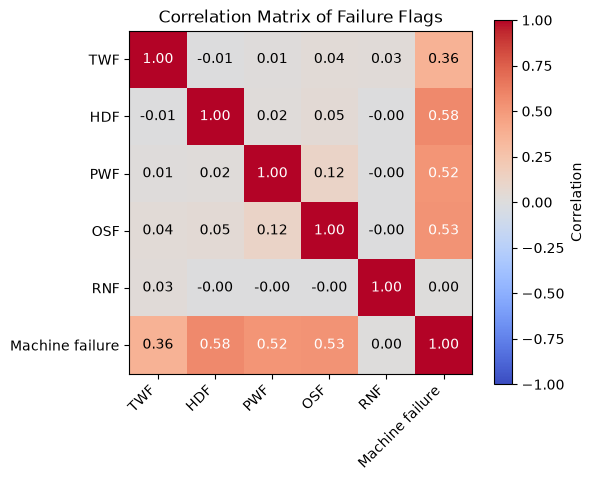

TWF vs Machine failure correlation: 0.36
HDF vs Machine failure correlation: 0.58
PWF vs Machine failure correlation: 0.52
OSF vs Machine failure correlation: 0.53
RNF vs Machine failure correlation: 0.00


In [90]:
# Compute correlation matrix for all failure flags
corrs = df[['TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Machine failure']].corr()

# Plot as a heatmap
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corrs, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(corrs.columns)))
ax.set_yticks(range(len(corrs.columns)))
ax.set_xticklabels(corrs.columns, rotation=45, ha='right')
ax.set_yticklabels(corrs.columns)

# Annotate each cell with its correlation value
for i in range(len(corrs.columns)):
    for j in range(len(corrs.columns)):
        value = corrs.iloc[i, j]
        ax.text(j, i, f'{value:.2f}', ha='center', va='center',
                 color='white' if abs(value) > 0.5 else 'black')

ax.set_title('Correlation Matrix of Failure Flags')
plt.colorbar(im, ax=ax, label='Correlation')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()


print(f"TWF vs Machine failure correlation: {df['TWF'].corr(df['Machine failure']):.2f}")
print(f"HDF vs Machine failure correlation: {df['HDF'].corr(df['Machine failure']):.2f}")
print(f"PWF vs Machine failure correlation: {df['PWF'].corr(df['Machine failure']):.2f}")
print(f"OSF vs Machine failure correlation: {df['OSF'].corr(df['Machine failure']):.2f}")
print(f"RNF vs Machine failure correlation: {df['RNF'].corr(df['Machine failure']):.2f}")


In [91]:
df['Diff temperature'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Power'] = df['Rotational speed [rpm]'] * df['Torque [Nm]']

In [92]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Diff temperature,Power
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0,9.6,47318.0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0,9.5,51897.6
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0,9.6,54943.0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0,9.7,68288.0


In [93]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [96]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Diff temperature', 'Power'],
      dtype='str')

In [100]:
df.drop(columns=['UDI'], inplace=True)
df.drop(columns=['Product ID'], inplace=True)

In [101]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Diff temperature,Power
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0


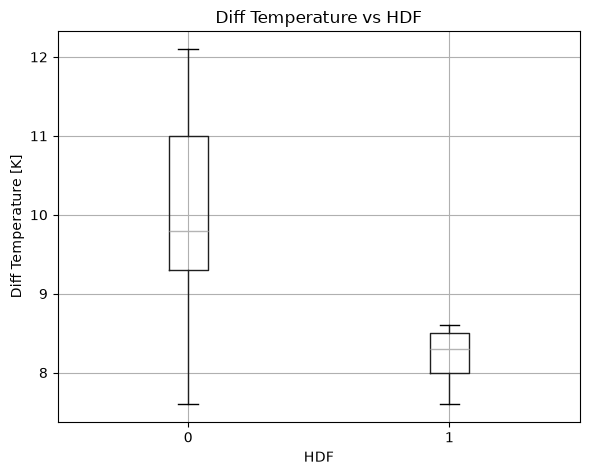

In [102]:
fig, ax = plt.subplots(figsize=(6,5))
df.boxplot(column='Diff temperature', by='HDF', ax=ax)
ax.set_xlabel('HDF')
ax.set_ylabel('Diff Temperature [K]')
ax.set_title('Diff Temperature vs HDF')
plt.suptitle('')  # removes the automatic pandas subtitle
plt.tight_layout()
plt.savefig('difftemp_vs_hdf_boxplot.png', dpi=150)
plt.show()

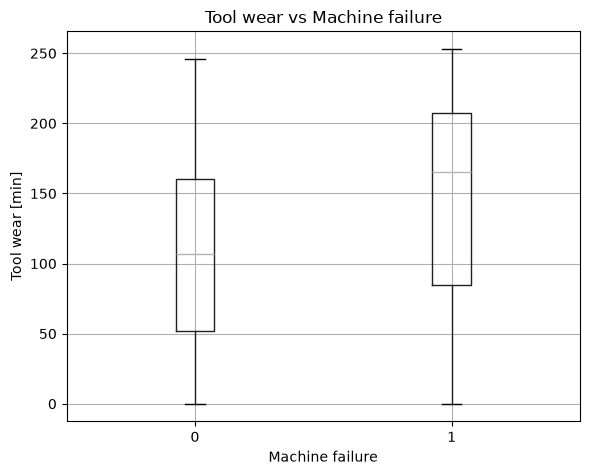

In [103]:
fig, ax = plt.subplots(figsize=(6,5))
df.boxplot(column='Tool wear [min]', by='Machine failure', ax=ax)
ax.set_xlabel('Machine failure')
ax.set_ylabel('Tool wear [min]')
ax.set_title('Tool wear vs Machine failure')
plt.suptitle('')  # removes the automatic pandas subtitle
plt.tight_layout()
plt.savefig('toolwear_vs_mf_boxplot.png', dpi=150)
plt.show()

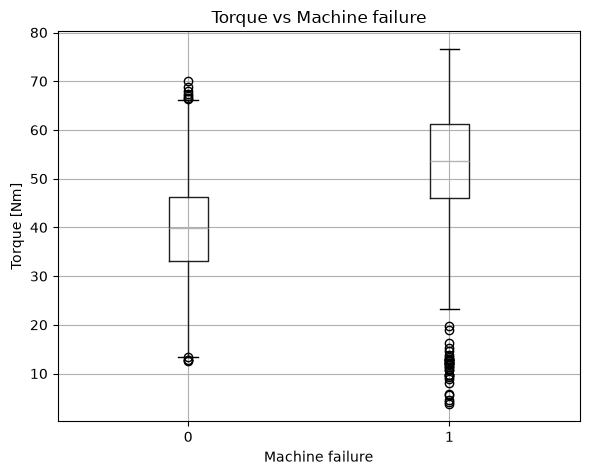

In [104]:
fig, ax = plt.subplots(figsize=(6,5))
df.boxplot(column='Torque [Nm]', by='Machine failure', ax=ax)
ax.set_xlabel('Machine failure')
ax.set_ylabel('Torque [Nm]')
ax.set_title('Torque vs Machine failure')
plt.suptitle('')  # removes the automatic pandas subtitle
plt.tight_layout()
plt.savefig('torque_vs_mf_boxplot.png', dpi=150)
plt.show()

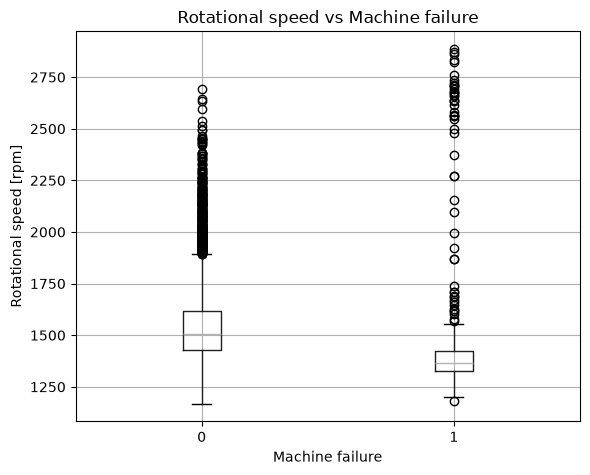

In [105]:
fig, ax = plt.subplots(figsize=(6,5))
df.boxplot(column='Rotational speed [rpm]', by='Machine failure', ax=ax)
ax.set_xlabel('Machine failure')
ax.set_ylabel('Rotational speed [rpm]')
ax.set_title('Rotational speed vs Machine failure')
plt.suptitle('')  # removes the automatic pandas subtitle
plt.tight_layout()
plt.savefig('rotational_speed_vs_mf_boxplot.png', dpi=150)
plt.show()

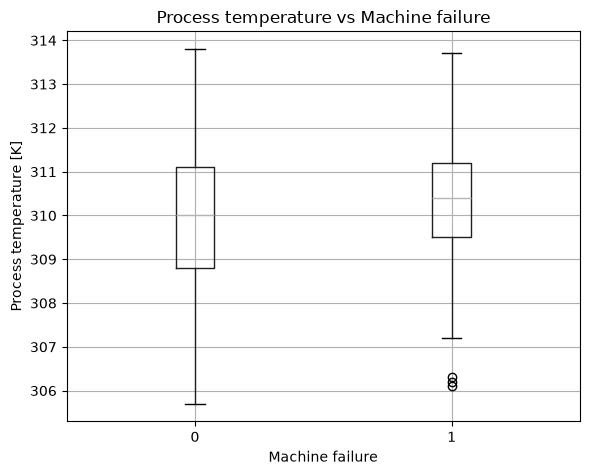

In [106]:
fig, ax = plt.subplots(figsize=(6,5))
df.boxplot(column='Process temperature [K]', by='Machine failure', ax=ax)
ax.set_xlabel('Machine failure')
ax.set_ylabel('Process temperature [K]')
ax.set_title('Process temperature vs Machine failure')
plt.suptitle('')  # removes the automatic pandas subtitle
plt.tight_layout()
plt.savefig('process_temperature_vs_mf_boxplot.png', dpi=150)
plt.show()

In [107]:
df["Tool wear bin"] = pd.cut(
    df["Tool wear [min]"],
    bins=[0, 50, 100, 150, 200, 250, 300],
    include_lowest=True
)

failure_rate = (
    df.groupby("Tool wear bin", observed=True)["Machine failure"]
    .mean() * 100
)

print('Failure rates by Tool wear bin:')
print(failure_rate)

print()




Failure rates by Tool wear bin:
Tool wear bin
(-0.001, 50.0]      2.170284
(50.0, 100.0]       2.333774
(100.0, 150.0]      2.178649
(150.0, 200.0]      2.899824
(200.0, 250.0]     15.263158
(250.0, 300.0]    100.000000
Name: Machine failure, dtype: float64



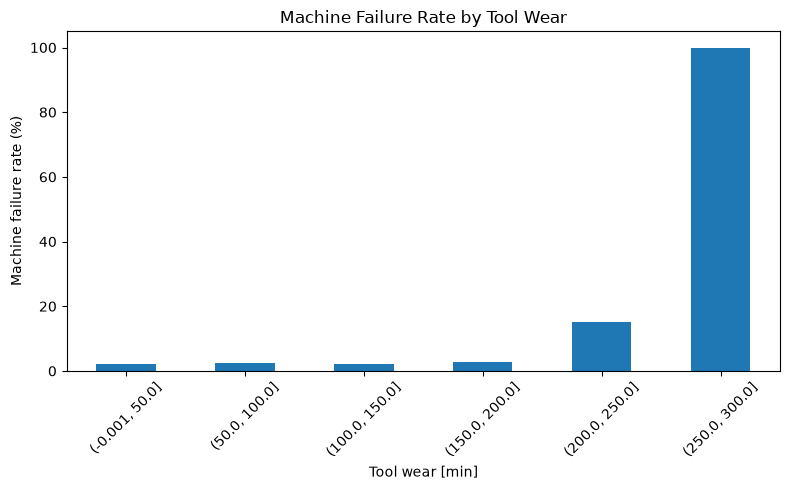

In [108]:
failure_rate.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Tool wear [min]")
plt.ylabel("Machine failure rate (%)")
plt.title("Machine Failure Rate by Tool Wear")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [111]:
df["Rotational speed bin"] = pd.cut(
    df["Rotational speed [rpm]"],
    bins=[1000, 1250, 1500, 1750, 2000, 2250],
    include_lowest=True
)

failure_rate = (
    df.groupby("Rotational speed bin", observed=True)["Machine failure"]
    .mean() * 100
)

print("Failure rates by Rotational speed bin:")
print(failure_rate)

print()

Failure rates by Rotational speed bin:
Rotational speed bin
(999.999, 1250.0]    25.000000
(1250.0, 1500.0]      5.485059
(1500.0, 1750.0]      0.584938
(1750.0, 2000.0]      0.536913
(2000.0, 2250.0]      1.342282
Name: Machine failure, dtype: float64



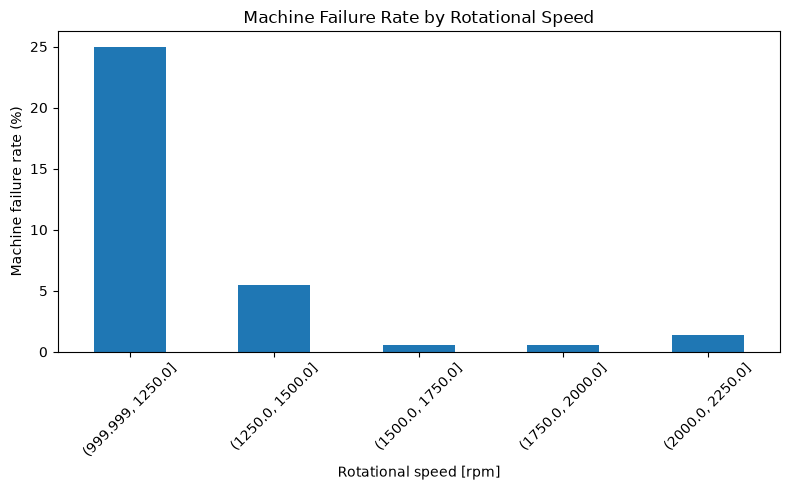

In [112]:
failure_rate.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Rotational speed [rpm]")
plt.ylabel("Machine failure rate (%)")
plt.title("Machine Failure Rate by Rotational Speed")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [74]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [113]:
df.groupby("Type")["Machine failure"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
Type,,,
H,1003,21,0.020937
L,6000,235,0.039167
M,2997,83,0.027694


In [115]:
failure_rate_type = (
    df.groupby("Type")["Machine failure"]
    .mean() * 100
)

print("Machine failure rates by machine type:")
print(failure_rate_type)

Machine failure rates by machine type:
Type
H    2.093719
L    3.916667
M    2.769436
Name: Machine failure, dtype: float64


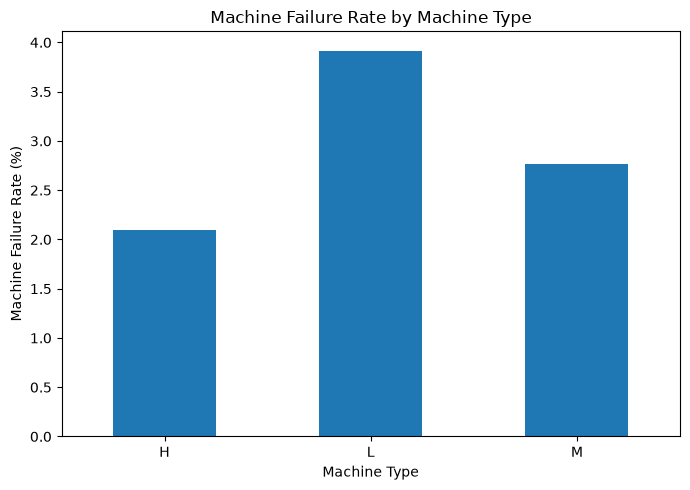

In [116]:
failure_rate_type.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("Machine Type")
plt.ylabel("Machine Failure Rate (%)")
plt.title("Machine Failure Rate by Machine Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

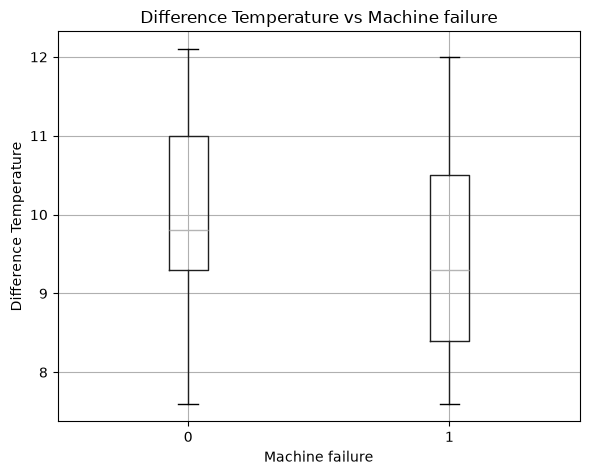

In [117]:
fig, ax = plt.subplots(figsize=(6,5))
df.boxplot(column='Diff temperature', by='Machine failure', ax=ax)
ax.set_xlabel('Machine failure')
ax.set_ylabel('Difference Temperature')
ax.set_title('Difference Temperature vs Machine failure')
plt.suptitle('')  # removes the automatic pandas subtitle
plt.tight_layout()
plt.savefig('diff_temp_vs_mf_boxplot.png', dpi=150)
plt.show()

# Feature Leakage Test      

In [122]:
Failure_modes =['TWF','HDF','PWF','OSF','RNF']
df[Failure_modes].describe().T

,count,mean,std,min,25%,50%,75%,max
TWF,10000.0,0.0046,0.067671,0.0,0.0,0.0,0.0,1.0
HDF,10000.0,0.0115,0.106625,0.0,0.0,0.0,0.0,1.0
PWF,10000.0,0.0095,0.097009,0.0,0.0,0.0,0.0,1.0
OSF,10000.0,0.0098,0.098514,0.0,0.0,0.0,0.0,1.0
RNF,10000.0,0.0019,0.043550,0.0,0.0,0.0,0.0,1.0


In [123]:
df[Failure_modes].sum().sort_values(ascending=False)

HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

In [124]:
df[Failure_modes].value_counts().head(10)

TWF  HDF  PWF  OSF  RNF
0    0    0    0    0      9652
     1    0    0    0       106
     0    1    0    0        80
          0    1    0        78
1    0    0    0    0        42
0    0    0    0    1        18
          1    1    0        11
     1    0    1    0         6
          1    0    0         3
1    0    0    1    0         2
Name: count, dtype: int64

In [125]:
failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]

for mode in failure_modes:
    print(f"\n{mode}")
    
    result = pd.crosstab(
        df[mode],
        df["Machine failure"],
        normalize="index"
    ) * 100
    
    print(result)


TWF
Machine failure         0          1
TWF                                 
0                97.05646    2.94354
1                 0.00000  100.00000

HDF
Machine failure         0          1
HDF                                 
0                97.73394    2.26606
1                 0.00000  100.00000

PWF
Machine failure          0           1
PWF                                   
0                97.536598    2.463402
1                 0.000000  100.000000

OSF
Machine failure          0           1
OSF                                   
0                97.566148    2.433852
1                 0.000000  100.000000

RNF
Machine failure          0         1
RNF                                 
0                96.613566  3.386434
1                94.736842  5.263158


# Leakage Assessment & Report
From the above, the failure mode indcators have a direct relationship with the target column which is the Machine Failure column. In each case, with exception to the Random Failure (RNF) column, whenever the indicators fire 1, the machine failure column also fired 1. 

The aim of the project is to predict machine failure from operating conditions. However, because the failure mode indicators will always provide the model with information  that is effectively an indicator of an already occurring failuire rather than information available for early prediction. 

RNF showed a weaker reltionship with the Machine Failure column but it will be excluded from the initial model because it also represents a failure indicator.

The predictive model will focus on the machine type and operation measurements such as temperature, rotational speed, torque, tool wear and added engineering features.